## Copyright and required citation

**Copyright (c) 2026 EBGS Authors.** Authors: Renhao Ye and Shiyin Shen.

This notebook is part of [EBGS](https://github.com/Rh-YE/EBGS) and is distributed under the repository's [MIT License](https://github.com/Rh-YE/EBGS/blob/main/LICENSE). Retain the copyright and license notices when copying or redistributing the software. Third-party components retain their respective notices.

**Citation requirement:** Cite the following paper in any research or publication that uses this notebook, the EBGS model, or images generated with it:

Renhao Ye and Shiyin Shen (2026), *From DESI to Euclid: A Generative Bridge to Unbiased Galaxy Structures*, [arXiv:2607.06891](https://arxiv.org/abs/2607.06891).

```bibtex
@article{ye2026desi2euclid,
  title   = {From DESI to Euclid: A Generative Bridge to Unbiased Galaxy Structures},
  author  = {Ye, Renhao and Shen, Shiyin},
  journal = {arXiv preprint arXiv:2607.06891},
  year    = {2026},
  eprint  = {2607.06891},
  archivePrefix = {arXiv},
  primaryClass  = {astro-ph.GA},
  url     = {https://arxiv.org/abs/2607.06891}
}
```


# Single-galaxy DESI → EBGS super-resolution demo (CPU / GPU, no stitching)

Enter RA and Dec to download a cutout automatically, or provide a local DESI **sky-subtracted, linear-flux FITS** image with either two channels (`r,z`) or three (`g,r,z`). The model generates an EBGS image in the style of Euclid VIS observations.
Following the production preprocessing, the input is resampled from 0.262″/pixel to 0.1″/pixel and cropped to the central **128×128 pixels, or 12.8″×12.8″**, for inference. No sliding windows or stitching are used.
Large galaxies may extend beyond this central field. The 0.1″ output sampling does not establish a measured physical resolution of 0.1″; the output is a model prediction rather than an actual Euclid observation.

This folder includes the source code, configuration, exported EMA weights, and example data for galaxy `1-10166`. The original repository and `/datapool` are not needed.
The default is `DEVICE="cpu"`, float32, and native PyTorch attention. CUDA, xformers, training, and additional model weights are not required once the complete folder is available.


## 1. Initial setup

Use Python **3.11–3.13**. Open a terminal in this folder, create and activate a virtual environment, then run:

```bash
python install.py
python -m jupyterlab single_galaxy_demo.ipynb
```

See `README.md` for virtual-environment commands on Windows, Linux, and macOS. Installing Python packages for the first time requires internet access. After installation, inference can run offline with local FITS files or cached cutouts; downloading a new target requires internet access.
`requirements.txt` lists third-party dependencies, and `sgm/` contains the required project source code. This folder does not include a Python interpreter or a preinstalled virtual environment.
For an existing CUDA environment, follow the GPU instructions in the README. Changing the device string alone does not add CUDA support to a CPU-only installation.

If you cloned the GitHub repository, install [Git LFS](https://git-lfs.com/) and run `git lfs pull` from the repository before opening this notebook. `weights/best_ema.safetensors` must contain the actual **129,668,236-byte** weights, not a small LFS pointer file. The complete standalone ZIP already contains the weights.


In [1]:
from pathlib import Path
import os
import sys
import tempfile
import time

# Start Jupyter in this folder or its parent directory.
ROOT = Path.cwd().resolve()
if not (ROOT / "inference.py").is_file() and (ROOT / "single_galaxy_demo/inference.py").is_file():
    ROOT = ROOT / "single_galaxy_demo"
assert (ROOT / "weights/best_ema.safetensors").is_file(), "Run this notebook from the complete single_galaxy_demo folder."
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".cache/matplotlib"))

# Coordinate mode: edit RA and DEC to download the input and run inference.
INPUT_MODE = "coordinates"                   # "coordinates" / "file"
RA = 199.2955574                             # ICRS right ascension in decimal degrees; 0 <= RA < 360.
DEC = 0.913561334                            # ICRS declination in decimal degrees; -90 <= DEC <= 90.
INPUT_BANDS = "grz"                          # "rz" / "grz"; file mode also accepts "auto".
LAYER = "ls-dr10"                            # Official combination: DR9 north / DR10 south.

# Edit the path below only in file mode; coordinate mode sets IMAGE_PATH automatically.
IMAGE_PATH = ROOT / "example/BGSUB/1-10166.fits"
# Local two-channel example:IMAGE_PATH = ROOT / "example/BGSUB/1-10166_rz.fits"
INPUT_PIXEL_SCALE = 0.262                     # Actual input scale in arcsec/pixel for file mode.
DEVICE = "cpu"                               # "cpu" / "cuda:0" / "auto"
CPU_THREADS = 4
SEED = 1024
NUM_SAMPLES = 3                               # Average 3 samples of the same central image, not 3 spatial tiles.
NFE = 10                                     # Matches the MaNGA production configuration.
SPLIT_RATIO = 0.7
print("Demo folder:", ROOT)


Demo folder: /data1/public/renhaoye/code/DESI2Euclid/single_galaxy_demo


## 2. Download an inference-input FITS cutout from RA and Dec

With `INPUT_MODE="coordinates"`, the notebook uses the [official Legacy Surveys cutout service](https://www.legacysurvey.org/dr10/description/#obtaining-images-and-raw-data). The default combines DR9 in the north with DR10 in the south, matching the data-release combination used for the MaNGA inputs.
The downloaded linear-flux FITS has shape `(2,128,128)` for rz or `(3,128,128)` for grz, a pixel scale of 0.262″/pixel, and celestial WCS metadata. Its path is passed directly to the next step. The central 12.8″ field is prepared afterward using the original preprocessing; downloading does not perform inference or stitching.

Coordinates are ICRS decimal degrees. A validated local cache with identical request parameters is reused; new coordinates require internet access. The downloader checks FITS format, band order, shape, image center, and invalid pixels. HTML responses and images that fail these checks are rejected.
Cutouts containing any exact-zero pixels are conservatively rejected to avoid using zero-filled regions with no observations. This may also reject legitimate zero values and is not a complete exposure-coverage audit.
The official coadd images are already sky-subtracted, so no additional sky subtraction or display stretch is applied. The viewer resamples onto the requested WCS; its pixels need not be bitwise identical to a cutout taken directly from a survey brick.


In [2]:
from download_cutout import download_cutout

if INPUT_MODE == "coordinates":
    # In coordinate mode, auto downloads grz; rz downloads only the r and z bands.
    requested_bands = "grz" if INPUT_BANDS == "auto" else INPUT_BANDS
    IMAGE_PATH = download_cutout(
        RA, DEC, bands=requested_bands, layer=LAYER,
        output_dir=ROOT / "downloads",
    )
    INPUT_BANDS = requested_bands
    INPUT_PIXEL_SCALE = 0.262
elif INPUT_MODE != "file":
    raise ValueError('INPUT_MODE must be "coordinates" or "file".')
print("Inference input FITS:", IMAGE_PATH)


Inference input FITS: /data1/public/renhaoye/code/DESI2Euclid/single_galaxy_demo/downloads/desi_199.295557_+0.913561_grz_a50f4721f464.fits


## 3. Read one galaxy and prepare the central input

The primary HDU must have shape `(2,H,W)` in `r,z` order or `(3,H,W)` in `g,r,z` order. `INPUT_BANDS="auto"` first reads the FITS `BANDS` keyword; if it is absent, the channel count determines the order above. Explicit band selection, header metadata, and channel count must agree. Use sky-subtracted, linear-flux data consistent with the training inputs, not JPEG, PNG, RGB composites, or arrays that have already been arcsinh-stretched.
The original 128×128-pixel example covers approximately 33.5″; the central 128×128 pixels after resampling cover 12.8″.

This demo preserves the production area-average resampling and `apply_zp_conv=False`, without additional per-image normalization or pixel-area flux correction.
For other data, confirm that the photometric units match the training inputs. Only the image is required: the interface neither accepts nor reads or writes error maps. The model always uses the r band as the bridge source and the z band as conditioning. When both input formats contain identical r/z data, they produce identical outputs with the same random seed.


In [3]:
import json
import numpy as np
import torch
from inference import prepare_input, load_model, generate, save_result

# This inference demo does not require a batch data loader, PSF files, or Euclid ground truth.
desi, output_header, input_info = prepare_input(
    IMAGE_PATH, bands=INPUT_BANDS, input_pixel_scale=INPUT_PIXEL_SCALE
)
print(json.dumps(input_info, indent=2, ensure_ascii=False))
print("Prepared DESI:", desi.shape, desi.dtype)
print("PyTorch:", torch.__version__)


{
  "input_file": "desi_199.295557_+0.913561_grz_a50f4721f464.fits",
  "input_sha256": "1324fedf480fdb798f53083c46080f65453a0050806e259f5456d7703abb09c2",
  "input_bands": "grz",
  "input_shape": [
    3,
    128,
    128
  ],
  "resampled_shape": [
    3,
    335,
    335
  ],
  "crop_yx": [
    103,
    103
  ],
  "output_shape": [
    128,
    128
  ],
  "input_pixel_scale_arcsec": 0.262,
  "output_pixel_scale_arcsec": 0.1,
  "field_arcsec": 12.8,
  "wcs_available": true,
  "preprocessing": "production fast area-average; center crop; apply_zp_conv=False"
}
Prepared DESI: (3, 128, 128) float32
PyTorch: 2.8.0+cpu


## 4. Load the final checkpoint's EMA weights

The weights come from `logs/2026-06-01T20-48-48_generation-astroIR_SBn/checkpoints/best.ckpt`, at epoch 332 and global step 86580.
Source checkpoint SHA-256: `788dbab951dd7f127aaada1f142191deaa52151708cb69c99da5ea456bd7bcb8`.

`weights/best_ema.safetensors` already contains the EMA parameters. Optimizer state and duplicate training weights were removed; all inference tensors remain float32, without quantization.
Accordingly, `use_ema=False` in the inference configuration means that a second EMA buffer is unnecessary, not that non-EMA weights are used.
Loading verifies the SHA-256 checksum and checks the model structure with `strict=True`. CPU and GPU inference use the same native attention implementation.


In [4]:
load_start = time.perf_counter()
model = load_model(device=DEVICE, cpu_threads=CPU_THREADS)
load_seconds = time.perf_counter() - load_start
print(f"Device: {model.device}; dtype: {next(model.parameters()).dtype}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Load time: {load_seconds:.2f} s; CPU threads: {torch.get_num_threads()}")


no module 'xformers'. Processing without...


Device: cpu; dtype: torch.float32
Parameters: 32,404,161
Load time: 2.07 s; CPU threads: 4


## 5. Generate the galaxy's EBGS image

The defaults match production: 10 steps and 3 stochastic samples sharing the first 70% of diffusion steps. Predictions are transformed back to physical values before averaging.
Set `NUM_SAMPLES=1` for a faster trial, but expect a different sampled result. CPU runtime and memory use depend on the computer; the measured inference time is printed below.
The random seed is reset before sampling. Bitwise equality is not guaranteed across CPU/GPU devices, numerical libraries, or the production bf16 path.


In [5]:
ebgs, inference_info = generate(
    model, desi, bands=input_info["input_bands"], seed=SEED, num_samples=NUM_SAMPLES,
    nfe=NFE, split_ratio=SPLIT_RATIO, verbose=False,
)
print(f"Generated: {ebgs.shape}, {ebgs.dtype}")
print(f"Inference: {inference_info['inference_seconds']:.2f} s on {inference_info['device']}")
print(f"Finite pixels: {np.isfinite(ebgs).sum()} / {ebgs.size}")
print(f"Raw output range: [{ebgs.min():.6g}, {ebgs.max():.6g}]")


/data/public/renhaoye/miniforge-pypy3/envs/ai4galaxy/lib/python3.13/contextlib.py:109: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)


Generated: (128, 128), float32
Inference: 4.69 s on cpu
Finite pixels: 16384 / 16384
Raw output range: [0.0427342, 2.06502]


## 6. Compare DESI and EBGS over the same field

For `grz` input, the demo uses the original repository's default `arcsinh_rgb` settings (`clip=True`). For `rz`, it displays the actual r and z bands separately in grayscale. EBGS is displayed with `arcsinh(50*x)/sqrt(50)` over its full minimum-to-maximum range, without percentile clipping.
These display operations do not alter the `ebgs` array or the saved FITS. All panels cover the same central field, and the DESI panels show the resampled input.


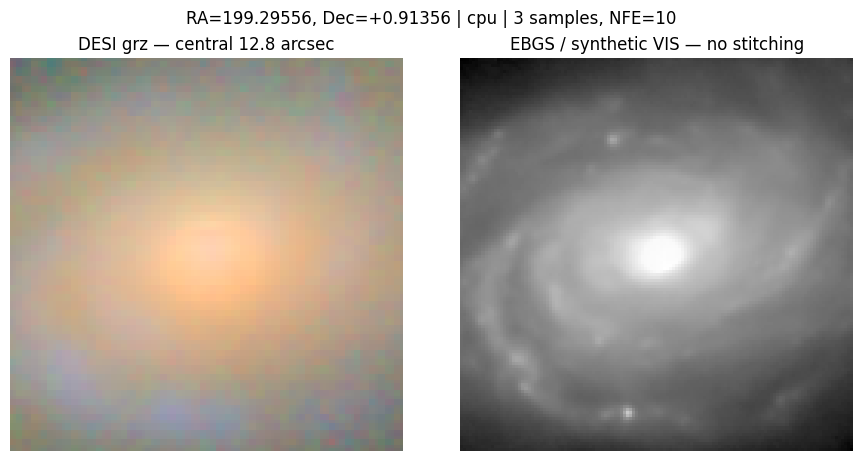

In [6]:
get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt
from display_utils import arcsinh_rgb

output_base = ROOT / "outputs"
output_base.mkdir(exist_ok=True)
RUN_DIR = Path(tempfile.mkdtemp(prefix=f"{IMAGE_PATH.stem}_{model.device.type}_", dir=output_base))

if input_info["input_bands"] == "grz":
    fig, axes = plt.subplots(1, 2, figsize=(9, 4.5), constrained_layout=True)
    axes[0].imshow(arcsinh_rgb(desi, mode="HWC"), origin="lower", interpolation="nearest")
    axes[0].set_title("DESI grz — central 12.8 arcsec")
else:
    fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
    for ax, band, plane in zip(axes[:2], "rz", desi):
        ax.imshow(np.arcsinh(50 * plane) / np.sqrt(50), origin="lower", cmap="gray", interpolation="nearest")
        ax.set_title(f"DESI {band} — central 12.8 arcsec")
axes[-1].imshow(np.arcsinh(50 * ebgs) / np.sqrt(50), origin="lower", cmap="gray", interpolation="nearest")
axes[-1].set_title("EBGS / synthetic VIS — no stitching")
for ax in axes:
    ax.set_axis_off()
target_label = output_header.get("MANGAID", IMAGE_PATH.stem)
if "MANGAID" not in output_header and "RA" in output_header and "DEC" in output_header:
    target_label = f"RA={output_header['RA']:.5f}, Dec={output_header['DEC']:+.5f}"
fig.suptitle(f"{target_label} | {model.device} | {NUM_SAMPLES} samples, NFE={NFE}")
FIGURE_PATH = RUN_DIR / f"{IMAGE_PATH.stem}_comparison.png"
fig.savefig(FIGURE_PATH, dpi=180)
plt.show()


## 7. Save the generated image

The output FITS contains a single primary HDU: the two-dimensional float32 EBGS image and its central-field WCS. It does not include input images or error maps.
A separate JSON file records the input and weight hashes, device, sampling parameters, and runtime. Each run creates a new output directory to avoid overwriting existing results.


In [7]:
metadata = {**input_info, **inference_info, "load_seconds": load_seconds}
FITS_PATH = save_result(
    RUN_DIR / f"{IMAGE_PATH.stem}_ebgs.fits", ebgs, output_header, metadata
)
print("FITS:", FITS_PATH)
print("Provenance:", FITS_PATH.with_suffix(".json"))
print("Comparison:", FIGURE_PATH)


FITS: /data1/public/renhaoye/code/DESI2Euclid/single_galaxy_demo/outputs/desi_199.295557_+0.913561_grz_a50f4721f464_cpu_7rttsw8w/desi_199.295557_+0.913561_grz_a50f4721f464_ebgs.fits
Provenance: /data1/public/renhaoye/code/DESI2Euclid/single_galaxy_demo/outputs/desi_199.295557_+0.913561_grz_a50f4721f464_cpu_7rttsw8w/desi_199.295557_+0.913561_grz_a50f4721f464_ebgs.json
Comparison: /data1/public/renhaoye/code/DESI2Euclid/single_galaxy_demo/outputs/desi_199.295557_+0.913561_grz_a50f4721f464_cpu_7rttsw8w/desi_199.295557_+0.913561_grz_a50f4721f464_comparison.png


To change targets in coordinate mode, edit `RA` and `DEC` in the first code cell, rerun that cell, and continue with downloading and inference. In local-file mode, edit `IMAGE_PATH`. You can reuse an already loaded model by skipping the model-loading cell.
Detailed CPU validation results are available in `validation/cpu_validation.json`. These checks establish rz/grz equivalence and consistency of the software and data flow; they do not independently validate the physical reality of generated structure.
